In [1]:
# Only needed if using Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap
import joblib

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [13]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree':       DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes':         GaussianNB(),
    'XGBoost':             XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE,
                                         verbosity=0),
    'XGBoost (balanced)':  XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE,
                                         scale_pos_weight=953/1032, verbosity=0),
    'LightGBM':            LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
}

In [14]:
from google.colab import files
uploaded = files.upload()  # select hypertention.csv again

DATA_PATH = list(uploaded.keys())[0]
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'\nColumns: {df.columns.tolist()}')
print(f'\nMissing values:\n{df.isnull().sum()}')
print(f'\nDuplicates: {df.duplicated().sum()}')
print(f'\nTarget distribution:\n{df["Has_Hypertension"].value_counts()}')
df.head()

Saving hypertention.csv to hypertention (1).csv
Dataset shape: 1985 rows × 12 columns

Columns: ['Unnamed: 0', 'Age', 'Salt_Intake', 'Stress_Score', 'BP_History', 'Sleep_Duration', 'BMI', 'Medication', 'Family_History', 'Exercise_Level', 'Smoking_Status', 'Has_Hypertension']

Missing values:
Unnamed: 0            0
Age                   0
Salt_Intake           0
Stress_Score          0
BP_History            0
Sleep_Duration        0
BMI                   0
Medication          799
Family_History        0
Exercise_Level        0
Smoking_Status        0
Has_Hypertension      0
dtype: int64

Duplicates: 0

Target distribution:
Has_Hypertension
Yes    1032
No      953
Name: count, dtype: int64


,Unnamed: 0,Age,Salt_Intake,Stress_Score,BP_History,Sleep_Duration,BMI,Medication,Family_History,Exercise_Level,Smoking_Status,Has_Hypertension
0,0,69,8.0,9,Normal,6.4,25.8,NaN,Yes,Low,Non-Smoker,Yes
1,1,32,11.7,10,Normal,5.4,23.4,NaN,No,Low,Non-Smoker,No
2,2,78,9.5,3,Normal,7.1,18.7,NaN,No,Moderate,Non-Smoker,No
3,3,38,10.0,10,Hypertension,4.2,22.1,ACE Inhibitor,No,Low,Non-Smoker,Yes
4,4,41,9.8,1,Prehypertension,5.8,16.2,Other,No,Moderate,Non-Smoker,No


In [15]:
# Drop the unnamed index column
df = df.drop(columns=['Unnamed: 0'])

# Fix Medication imputation:
# 799 missing values = 40% of data — these are likely patients on NO medication
# Imputing with mode (Beta Blocker) would be clinically wrong
# Correct approach: fill with 'None' as a new category
df['Medication'] = df['Medication'].fillna('None')

print(f'Shape after dropping index column: {df.shape}')
print(f'\nMedication value counts after fix:')
print(df['Medication'].value_counts())
print(f'\nAny missing values remaining: {df.isnull().sum().sum()}')

Shape after dropping index column: (1985, 11)

Medication value counts after fix:
Medication
None             799
Beta Blocker     412
ACE Inhibitor    323
Diuretic         245
Other            206
Name: count, dtype: int64

Any missing values remaining: 0


In [16]:
# Encode target: Yes=1, No=0
df['Has_Hypertension'] = df['Has_Hypertension'].map({'Yes': 1, 'No': 0})

TARGET = 'Has_Hypertension'

# Numerical features
NUM_FEATURES = ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI']

# Categorical — FULL set (includes leakage features for comparison)
CAT_FEATURES_FULL = ['BP_History', 'Medication', 'Family_History',
                     'Exercise_Level', 'Smoking_Status']

# Categorical — CORRECTED set (lifestyle + demographic only, no leakage)
CAT_FEATURES_CORRECTED = ['Family_History', 'Exercise_Level', 'Smoking_Status']

print('Target encoded: Yes=1, No=0')
print(f'\nFull feature set:      {NUM_FEATURES + CAT_FEATURES_FULL}')
print(f'Corrected feature set: {NUM_FEATURES + CAT_FEATURES_CORRECTED}')
print(f'\nTarget distribution after encoding:\n{df[TARGET].value_counts()}')

Target encoded: Yes=1, No=0

Full feature set:      ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI', 'BP_History', 'Medication', 'Family_History', 'Exercise_Level', 'Smoking_Status']
Corrected feature set: ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI', 'Family_History', 'Exercise_Level', 'Smoking_Status']

Target distribution after encoding:
Has_Hypertension
1    1032
0     953
Name: count, dtype: int64


In [17]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE    = 0.20

def build_preprocessor(num_features, cat_features):
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ])

preprocessor_full      = build_preprocessor(NUM_FEATURES, CAT_FEATURES_FULL)
preprocessor_corrected = build_preprocessor(NUM_FEATURES, CAT_FEATURES_CORRECTED)

# Define X for both feature sets
X_full      = df[NUM_FEATURES + CAT_FEATURES_FULL]
X_corrected = df[NUM_FEATURES + CAT_FEATURES_CORRECTED]
y           = df[TARGET]

# Stratified split — same indices for both sets so results are comparable
X_full_train, X_full_test, y_train, y_test = train_test_split(
    X_full, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_corr_train, X_corr_test, _, _ = train_test_split(
    X_corrected, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Fit preprocessor on training data ONLY — then transform both
# (fitting on full data before splitting would be data leakage)
X_full_train_proc = preprocessor_full.fit_transform(X_full_train)
X_full_test_proc  = preprocessor_full.transform(X_full_test)

X_corr_train_proc = preprocessor_corrected.fit_transform(X_corr_train)
X_corr_test_proc  = preprocessor_corrected.transform(X_corr_test)

print(f'Train size: {X_full_train.shape[0]} | Test size: {X_full_test.shape[0]}')
print(f'\nClass balance in train — y=1: {y_train.sum()} ({y_train.mean()*100:.1f}%)')
print(f'Class balance in test  — y=1: {y_test.sum()} ({y_test.mean()*100:.1f}%)')
print(f'\nFull feature matrix      — Train: {X_full_train_proc.shape} | Test: {X_full_test_proc.shape}')
print(f'Corrected feature matrix — Train: {X_corr_train_proc.shape} | Test: {X_corr_test_proc.shape}')
print('\n✅ Preprocessing complete. Ready for EDA and modelling.')

Train size: 1588 | Test size: 397

Class balance in train — y=1: 826 (52.0%)
Class balance in test  — y=1: 206 (51.9%)

Full feature matrix      — Train: (1588, 20) | Test: (397, 20)
Corrected feature matrix — Train: (1588, 12) | Test: (397, 12)

✅ Preprocessing complete. Ready for EDA and modelling.


Cell 7 — Numerical distributions by hypertension status

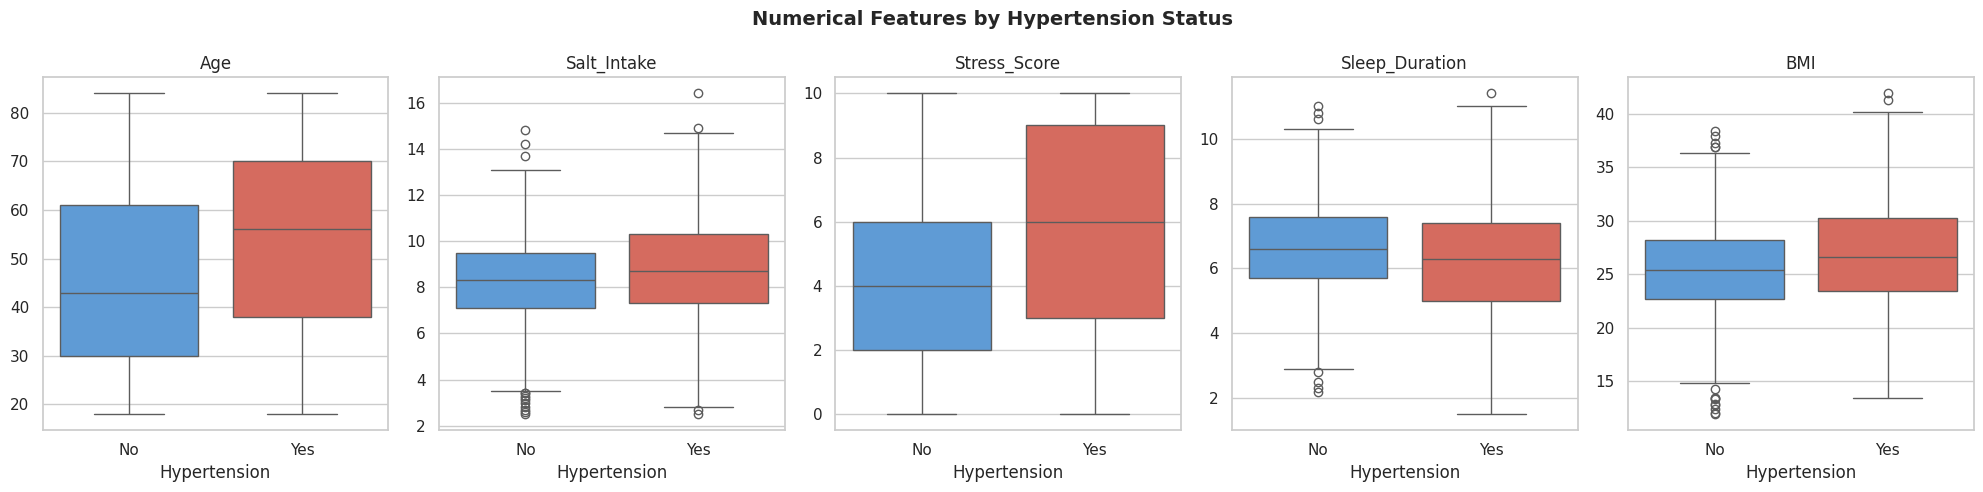

Figure 1 saved.


In [18]:
# Cell 7 — Fixed for newer seaborn version
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Numerical Features by Hypertension Status', fontsize=14, fontweight='bold')

# Create a string label version for plotting
df_plot = df.copy()
df_plot['Hypertension_Label'] = df_plot['Has_Hypertension'].map({0: 'No', 1: 'Yes'})

for ax, col in zip(axes, NUM_FEATURES):
    sns.boxplot(data=df_plot, x='Hypertension_Label', y=col, ax=ax,
                hue='Hypertension_Label',
                palette={'No': '#4C9BE8', 'Yes': '#E85C4C'},
                order=['No', 'Yes'], legend=False)
    ax.set_title(col)
    ax.set_xlabel('Hypertension')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('fig1_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

Cell 8 — Categorical features by hypertension status

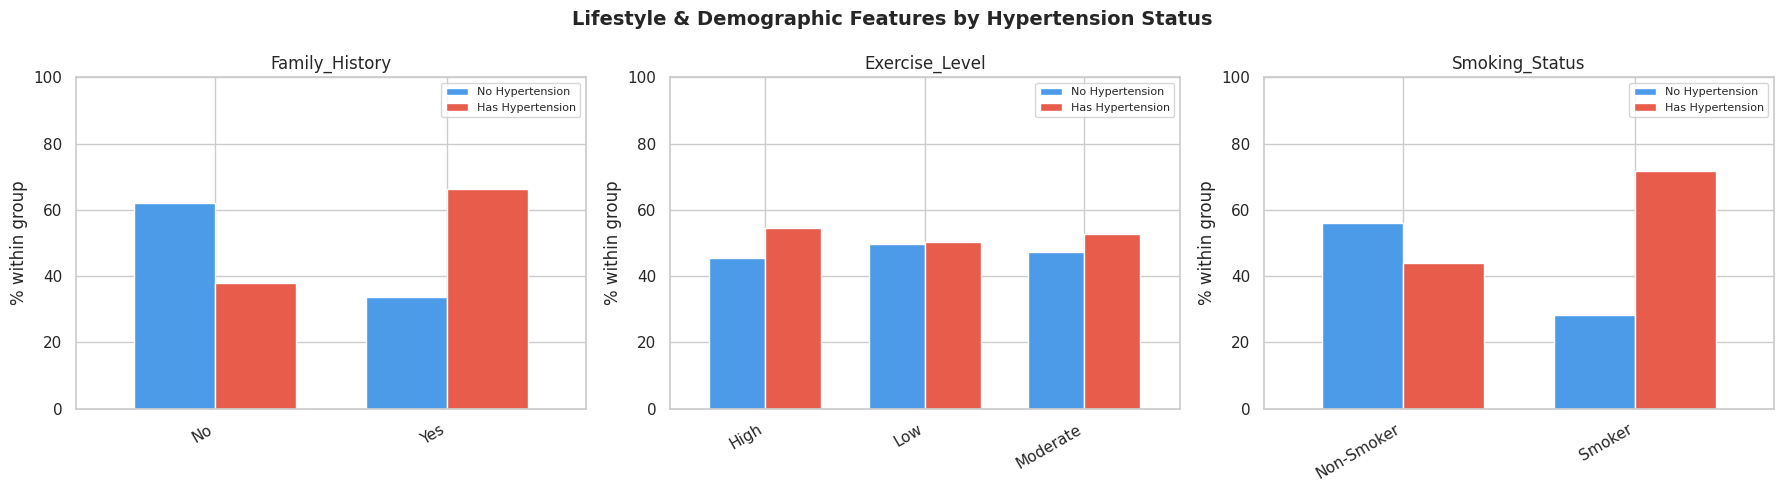

Figure 2 saved.


In [19]:
# Cell 8 — Fixed categorical plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Lifestyle & Demographic Features by Hypertension Status',
             fontsize=14, fontweight='bold')

for ax, col in zip(axes, CAT_FEATURES_CORRECTED):
    ct = pd.crosstab(df_plot[col], df_plot['Hypertension_Label'],
                     normalize='index') * 100
    # Ensure column order is consistent
    for c in ['No', 'Yes']:
        if c not in ct.columns:
            ct[c] = 0
    ct = ct[['No', 'Yes']]
    ct.columns = ['No Hypertension', 'Has Hypertension']
    ct.plot(kind='bar', ax=ax, color=['#4C9BE8', '#E85C4C'],
            edgecolor='white', width=0.7)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('% within group')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('fig2_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

Cell 9 — Correlation heatmap (corrected feature set)

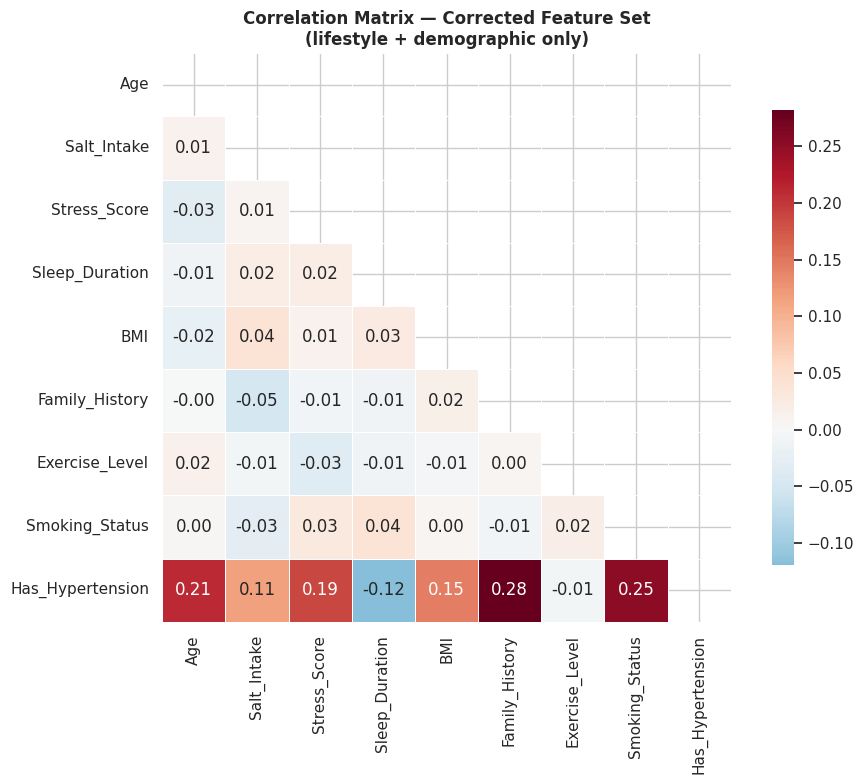


=== Correlations with Has_Hypertension ===
Family_History    0.282
Smoking_Status    0.251
Age               0.211
Stress_Score      0.187
BMI               0.145
Salt_Intake       0.114
Exercise_Level   -0.007
Sleep_Duration   -0.120


In [20]:
# Build a version of the corrected features with ordinal encoding for correlation
df_corr = df[NUM_FEATURES + CAT_FEATURES_CORRECTED + [TARGET]].copy()

# Encode categoricals ordinally just for correlation calculation
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder()
df_corr[CAT_FEATURES_CORRECTED] = oe.fit_transform(df_corr[CAT_FEATURES_CORRECTED])

correlation = df_corr.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(correlation, dtype=bool))  # show lower triangle only
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, mask=mask, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Corrected Feature Set\n(lifestyle + demographic only)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print correlations with target specifically
print('\n=== Correlations with Has_Hypertension ===')
print(correlation['Has_Hypertension'].drop('Has_Hypertension').sort_values(
    ascending=False).round(3).to_string())

Cell 10 — Age group analysis (Table 1 component)

In [21]:
bins   = [0, 30, 40, 50, 60, 100]
labels = ['≤30', '31–40', '41–50', '51–60', '>60']

df_age = df.copy()
df_age['Age_Group'] = pd.cut(df_age['Age'], bins=bins, labels=labels, right=False)

summary = df_age.groupby('Age_Group', observed=False).agg(
    N            = ('Age', 'count'),
    Hypertension = ('Has_Hypertension', 'sum'),
    Mean_Age     = ('Age', 'mean'),
    Mean_BMI     = ('BMI', 'mean'),
    Mean_Stress  = ('Stress_Score', 'mean'),
    Mean_Salt    = ('Salt_Intake', 'mean'),
    Mean_Sleep   = ('Sleep_Duration', 'mean')
).reset_index()

summary['% of Dataset']      = (summary['N'] / len(df) * 100).round(1)
summary['% with Hypertension'] = (summary['Hypertension'] / summary['N'] * 100).round(1)
summary['Mean_Age']   = summary['Mean_Age'].round(1)
summary['Mean_BMI']   = summary['Mean_BMI'].round(1)
summary['Mean_Stress'] = summary['Mean_Stress'].round(1)
summary['Mean_Salt']  = summary['Mean_Salt'].round(1)
summary['Mean_Sleep'] = summary['Mean_Sleep'].round(1)

print('=== Age Group Summary (contributes to Table 1) ===')
display(summary[['Age_Group', 'N', '% of Dataset', 'Hypertension',
                  '% with Hypertension', 'Mean_BMI', 'Mean_Stress',
                  'Mean_Salt', 'Mean_Sleep']])

=== Age Group Summary (contributes to Table 1) ===


,Age_Group,N,% of Dataset,Hypertension,% with Hypertension,Mean_BMI,Mean_Stress,Mean_Salt,Mean_Sleep
0,≤30,373,18.8,154,41.3,26.3,5.3,8.4,6.6
1,31–40,304,15.3,113,37.2,25.9,5.0,8.6,6.3
2,41–50,297,15.0,118,39.7,26.0,4.9,8.7,6.5
3,51–60,301,15.2,186,61.8,26.0,4.8,8.6,6.5
4,>60,710,35.8,461,64.9,25.9,4.9,8.5,6.4


Cell 11 — Target distribution plot

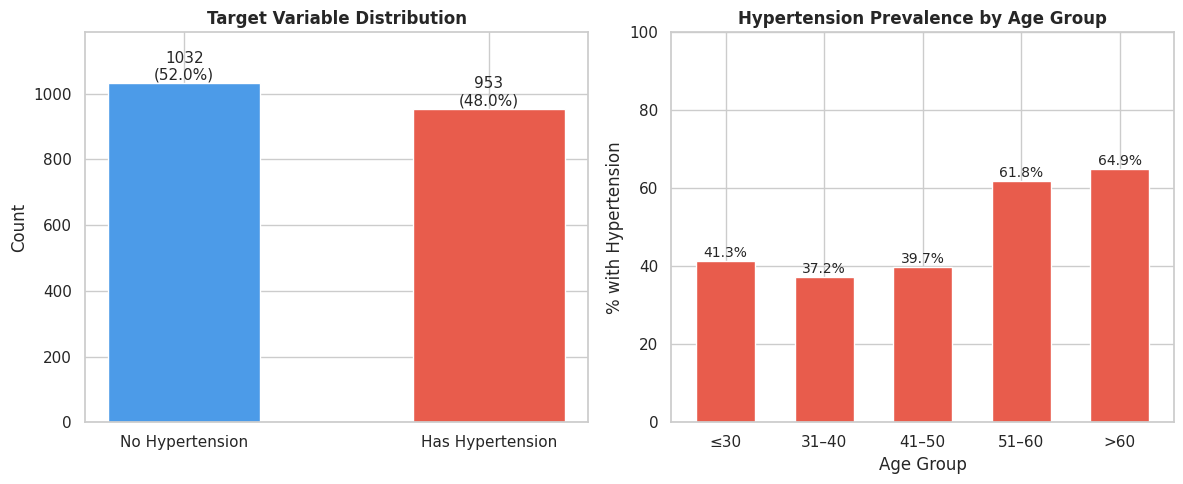

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Overall distribution
counts = df['Has_Hypertension'].value_counts()
axes[0].bar(['No Hypertension', 'Has Hypertension'], counts.values,
            color=['#4C9BE8', '#E85C4C'], edgecolor='white', width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, f'{v}\n({v/len(df)*100:.1f}%)',
                 ha='center', fontsize=11)
axes[0].set_title('Target Variable Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, max(counts.values) * 1.15)

# By age group
pivot = df_age.groupby('Age_Group', observed=False)['Has_Hypertension'].mean() * 100
pivot.plot(kind='bar', ax=axes[1], color='#E85C4C', edgecolor='white', width=0.6)
axes[1].set_title('Hypertension Prevalence by Age Group', fontweight='bold')
axes[1].set_ylabel('% with Hypertension')
axes[1].set_xlabel('Age Group')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].set_ylim(0, 100)

for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 1),
                     ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig4_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
# Fix LightGBM feature name warning
# Convert processed arrays to DataFrames with proper column names

def get_feature_names(preprocessor, num_features, cat_features):
    """Get feature names after OneHotEncoding."""
    cat_encoder   = preprocessor.named_transformers_['cat']
    cat_names     = cat_encoder.get_feature_names_out(cat_features).tolist()
    return num_features + cat_names

# Rebuild as DataFrames
full_cols = get_feature_names(preprocessor_full, NUM_FEATURES, CAT_FEATURES_FULL)
corr_cols = get_feature_names(preprocessor_corrected, NUM_FEATURES, CAT_FEATURES_CORRECTED)

X_full_train_proc = pd.DataFrame(X_full_train_proc, columns=full_cols)
X_full_test_proc  = pd.DataFrame(X_full_test_proc,  columns=full_cols)
X_corr_train_proc = pd.DataFrame(X_corr_train_proc, columns=corr_cols)
X_corr_test_proc  = pd.DataFrame(X_corr_test_proc,  columns=corr_cols)

print('Feature names assigned.')
print(f'Full columns:      {full_cols}')
print(f'\nCorrected columns: {corr_cols}')

Feature names assigned.
Full columns:      ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI', 'BP_History_Hypertension', 'BP_History_Normal', 'BP_History_Prehypertension', 'Medication_ACE Inhibitor', 'Medication_Beta Blocker', 'Medication_Diuretic', 'Medication_None', 'Medication_Other', 'Family_History_No', 'Family_History_Yes', 'Exercise_Level_High', 'Exercise_Level_Low', 'Exercise_Level_Moderate', 'Smoking_Status_Non-Smoker', 'Smoking_Status_Smoker']

Corrected columns: ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI', 'Family_History_No', 'Family_History_Yes', 'Exercise_Level_High', 'Exercise_Level_Low', 'Exercise_Level_Moderate', 'Smoking_Status_Non-Smoker', 'Smoking_Status_Smoker']


Cell 12 — Train all models on both feature sets:

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score)

# ── Model definitions ─────────────────────────────────────────────────────────
def get_models():
    """Return a fresh set of uninitialised models each time — avoids state carry-over."""
    return {
        'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'Decision Tree':        DecisionTreeClassifier(random_state=RANDOM_STATE),
        'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
        'KNN':                  KNeighborsClassifier(n_neighbors=5),
        'Naive Bayes':          GaussianNB(),
        'XGBoost':              XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE,
                                              verbosity=0),
        'XGBoost (balanced)':   XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE,
                                              scale_pos_weight=953/1032, verbosity=0),
        'LightGBM':             LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
    }

# ── Evaluation function ───────────────────────────────────────────────────────
def evaluate_models(models, X_train, X_test, y_train, y_test, label):
    """Train and evaluate all models. Returns results dataframe and trained model dict."""
    results = []
    trained = {}

    for name, model in models.items():
        print(f'  Training {name}...', end=' ')
        model.fit(X_train, y_train)
        y_pred  = model.predict(X_test)
        y_proba = (model.predict_proba(X_test)[:, 1]
                   if hasattr(model, 'predict_proba') else None)

        row = {
            'Model':       name,
            'Feature Set': label,
            'Accuracy':    round(accuracy_score(y_test, y_pred),  4),
            'Precision':   round(precision_score(y_test, y_pred), 4),
            'Recall':      round(recall_score(y_test, y_pred),    4),
            'F1 Score':    round(f1_score(y_test, y_pred),        4),
            'ROC-AUC':     round(roc_auc_score(y_test, y_proba),  4)
                           if y_proba is not None else None
        }
        results.append(row)
        trained[name] = model
        print('done.')

    return pd.DataFrame(results), trained

# ── Run on FULL feature set (leakage features included — for comparison only) ─
print('=' * 60)
print('TRAINING — FULL FEATURE SET (includes BP_History + Medication)')
print('=' * 60)
results_full, models_full = evaluate_models(
    get_models(),
    X_full_train_proc, X_full_test_proc,
    y_train, y_test,
    'Full (with leakage)'
)

# ── Run on CORRECTED feature set (main analysis) ──────────────────────────────
print('\n' + '=' * 60)
print('TRAINING — CORRECTED FEATURE SET (lifestyle + demographic only)')
print('=' * 60)
results_corr, models_corr = evaluate_models(
    get_models(),
    X_corr_train_proc, X_corr_test_proc,
    y_train, y_test,
    'Corrected (no leakage)'
)

# ── Display results ───────────────────────────────────────────────────────────
print('\n' + '=' * 60)
print('RESULTS — FULL FEATURE SET')
print('=' * 60)
display(results_full[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']])

print('\n' + '=' * 60)
print('RESULTS — CORRECTED FEATURE SET')
print('=' * 60)
display(results_corr[['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']])

# ── Combined for later use ────────────────────────────────────────────────────
results_all = pd.concat([results_full, results_corr], ignore_index=True)
print('\n✅ All models trained and evaluated.')

TRAINING — FULL FEATURE SET (includes BP_History + Medication)
  Training Logistic Regression... done.
  Training Decision Tree... done.
  Training Random Forest... done.
  Training KNN... done.
  Training Naive Bayes... done.
  Training XGBoost... done.
  Training XGBoost (balanced)... done.
  Training LightGBM... done.

TRAINING — CORRECTED FEATURE SET (lifestyle + demographic only)
  Training Logistic Regression... done.
  Training Decision Tree... done.
  Training Random Forest... done.
  Training KNN... done.
  Training Naive Bayes... done.
  Training XGBoost... done.
  Training XGBoost (balanced)... done.
  Training LightGBM... done.

RESULTS — FULL FEATURE SET


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8715,0.8856,0.8641,0.8747,0.9537
1,Decision Tree,0.9597,0.9567,0.9660,0.9614,0.9594
2,Random Forest,0.9446,0.9694,0.9223,0.9453,0.9903
3,KNN,0.8615,0.9037,0.8204,0.8601,0.9228
4,Naive Bayes,0.8212,0.8771,0.7621,0.8156,0.9163
5,XGBoost,0.9673,0.9573,0.9806,0.9688,0.9983
6,XGBoost (balanced),0.9723,0.9621,0.9854,0.9736,0.9988
7,LightGBM,0.9798,0.9670,0.9951,0.9809,0.9983



RESULTS — CORRECTED FEATURE SET


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7506,0.7512,0.7767,0.7637,0.8358
1,Decision Tree,0.6977,0.6792,0.7913,0.7309,0.6941
2,Random Forest,0.7708,0.7889,0.7621,0.7753,0.8534
3,KNN,0.7280,0.7606,0.6942,0.7259,0.7975
4,Naive Bayes,0.7204,0.7251,0.7427,0.7338,0.8170
5,XGBoost,0.7683,0.7767,0.7767,0.7767,0.8503
6,XGBoost (balanced),0.7657,0.7678,0.7864,0.7770,0.8651
7,LightGBM,0.7683,0.7767,0.7767,0.7767,0.8565



✅ All models trained and evaluated.


Cell 13 — Updated comparison chart for 8 models:

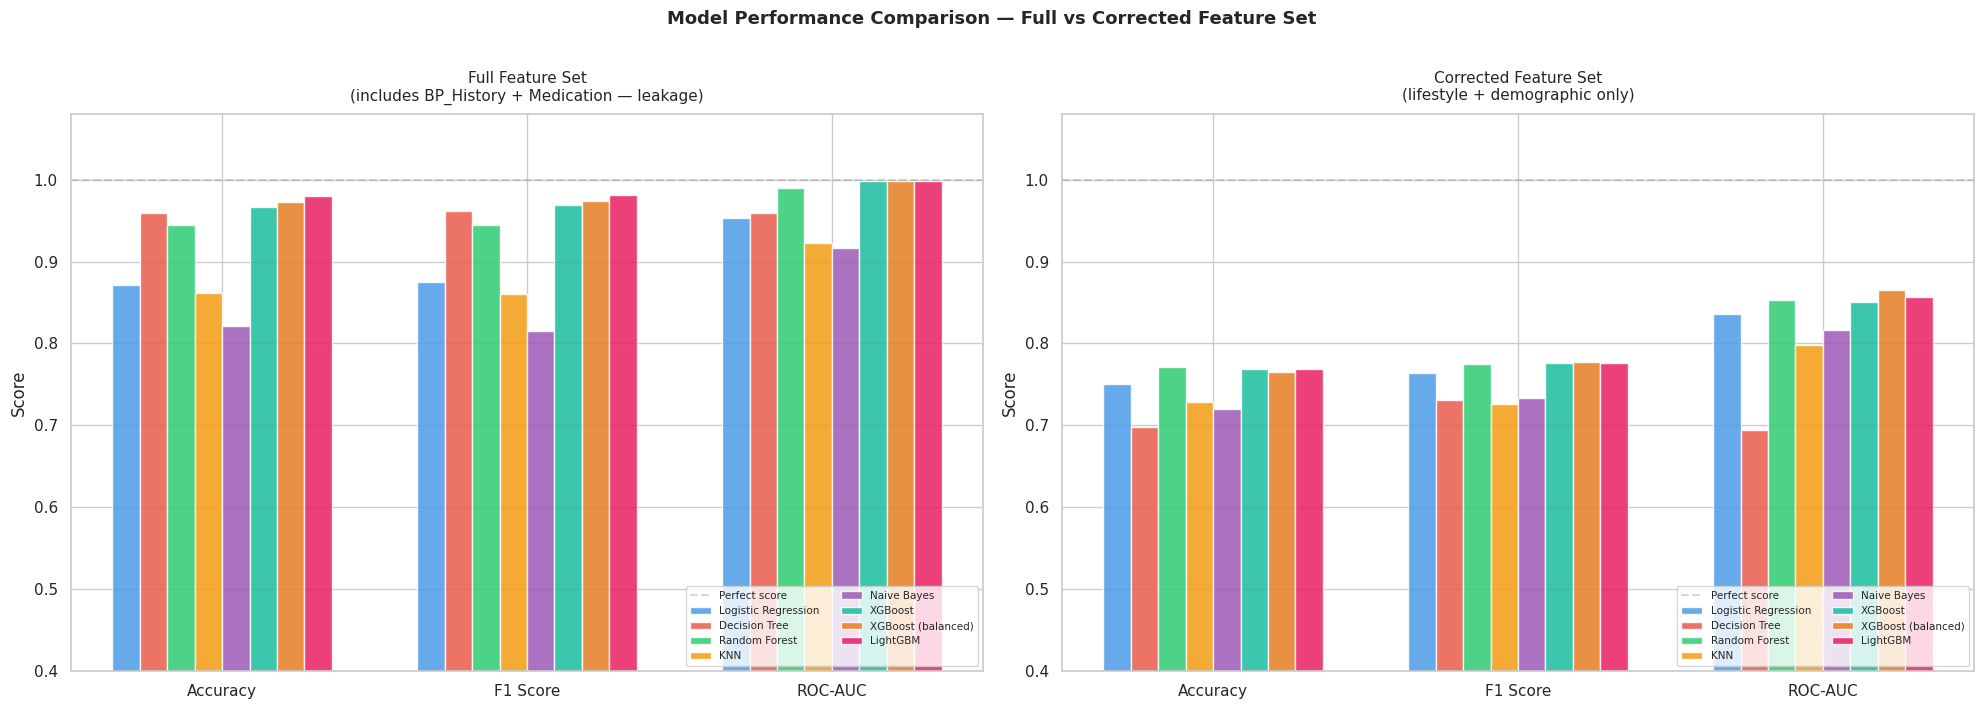

Figure 5 saved.


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle('Model Performance Comparison — Full vs Corrected Feature Set',
             fontsize=13, fontweight='bold', y=1.01)

metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']
colors  = ['#4C9BE8', '#E85C4C', '#2ECC71', '#F39C12',
           '#9B59B6', '#1ABC9C', '#E67E22', '#E91E63']
x       = np.arange(len(metrics))
n       = len(results_full)          # number of models (8)
width   = 0.09                       # narrower bars to fit 8 models

for ax, (results, title) in zip(axes, [
    (results_full, 'Full Feature Set\n(includes BP_History + Medication — leakage)'),
    (results_corr, 'Corrected Feature Set\n(lifestyle + demographic only)')
]):
    for i, (_, row) in enumerate(results.iterrows()):
        vals   = [row['Accuracy'], row['F1 Score'], row['ROC-AUC']]
        offset = (i - n/2) * width + width/2
        ax.bar(x + offset, vals, width, label=row['Model'],
               color=colors[i], alpha=0.85, edgecolor='white')

    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=11)
    ax.set_ylim(0.4, 1.08)
    ax.set_ylabel('Score')
    ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3, label='Perfect score')
    ax.legend(fontsize=7.5, loc='lower right', ncol=2)

plt.tight_layout()
plt.savefig('fig5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

Cell 13b — Ranked summary table (bonus — useful for the paper):

In [30]:
# Best model per metric in each feature set
print('=== BEST MODEL PER METRIC — FULL FEATURE SET ===')
for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']:
    best_idx = results_full[metric].idxmax()
    print(f'  {metric:12s}: {results_full.loc[best_idx, "Model"]} '
          f'({results_full.loc[best_idx, metric]:.4f})')

print('\n=== BEST MODEL PER METRIC — CORRECTED FEATURE SET ===')
for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']:
    best_idx = results_corr[metric].idxmax()
    print(f'  {metric:12s}: {results_corr.loc[best_idx, "Model"]} '
          f'({results_corr.loc[best_idx, metric]:.4f})')

print('\n=== PERFORMANCE DROP — Full vs Corrected (XGBoost) ===')
xgb_full = results_full[results_full['Model'] == 'XGBoost'].iloc[0]
xgb_corr = results_corr[results_corr['Model'] == 'XGBoost'].iloc[0]
for metric in ['Accuracy', 'F1 Score', 'ROC-AUC']:
    drop = xgb_full[metric] - xgb_corr[metric]
    print(f'  {metric:12s}: {xgb_full[metric]:.4f} → {xgb_corr[metric]:.4f} '
          f'(Δ = {drop:+.4f})')

=== BEST MODEL PER METRIC — FULL FEATURE SET ===
  Accuracy    : LightGBM (0.9798)
  Precision   : Random Forest (0.9694)
  Recall      : LightGBM (0.9951)
  F1 Score    : LightGBM (0.9809)
  ROC-AUC     : XGBoost (balanced) (0.9988)

=== BEST MODEL PER METRIC — CORRECTED FEATURE SET ===
  Accuracy    : Random Forest (0.7708)
  Precision   : Random Forest (0.7889)
  Recall      : Decision Tree (0.7913)
  F1 Score    : XGBoost (balanced) (0.7770)
  ROC-AUC     : XGBoost (balanced) (0.8651)

=== PERFORMANCE DROP — Full vs Corrected (XGBoost) ===
  Accuracy    : 0.9673 → 0.7683 (Δ = +0.1990)
  F1 Score    : 0.9688 → 0.7767 (Δ = +0.1921)
  ROC-AUC     : 0.9983 → 0.8503 (Δ = +0.1480)


Step 4

Cell 14 — Stratified K-Fold Cross-Validation (corrected feature set — main analysis):

In [31]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import warnings
warnings.filterwarnings('ignore')

# Use the full corrected feature matrix (not just train split)
# Cross-validation handles splitting internally
X_cv = pd.DataFrame(
    preprocessor_corrected.fit_transform(X_corrected),
    columns=corr_cols
)
y_cv = y.reset_index(drop=True)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_results = {}

print('Running 10-fold stratified cross-validation — Corrected Feature Set')
print('=' * 65)

for name, model in get_models().items():
    scores = cross_validate(model, X_cv, y_cv, cv=cv,
                            scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'Accuracy':  scores['test_accuracy'],
        'Precision': scores['test_precision'],
        'Recall':    scores['test_recall'],
        'F1 Score':  scores['test_f1'],
        'ROC-AUC':   scores['test_roc_auc']
    }
    print(f"  {name:<25} Acc: {scores['test_accuracy'].mean():.4f} ± "
          f"{scores['test_accuracy'].std():.4f} | "
          f"ROC-AUC: {scores['test_roc_auc'].mean():.4f} ± "
          f"{scores['test_roc_auc'].std():.4f}")

print('\n✅ Cross-validation complete.')

Running 10-fold stratified cross-validation — Corrected Feature Set
  Logistic Regression       Acc: 0.7174 ± 0.0217 | ROC-AUC: 0.8070 ± 0.0213
  Decision Tree             Acc: 0.7264 ± 0.0312 | ROC-AUC: 0.7253 ± 0.0310
  Random Forest             Acc: 0.7532 ± 0.0250 | ROC-AUC: 0.8377 ± 0.0252
  KNN                       Acc: 0.7058 ± 0.0271 | ROC-AUC: 0.7729 ± 0.0255
  Naive Bayes               Acc: 0.6997 ± 0.0312 | ROC-AUC: 0.7845 ± 0.0236
  XGBoost                   Acc: 0.7602 ± 0.0302 | ROC-AUC: 0.8417 ± 0.0262
  XGBoost (balanced)        Acc: 0.7502 ± 0.0331 | ROC-AUC: 0.8404 ± 0.0222
  LightGBM                  Acc: 0.7688 ± 0.0296 | ROC-AUC: 0.8484 ± 0.0270

✅ Cross-validation complete.


Cell 15 — Cross-validation summary table:

In [32]:
# Build summary dataframe — mean ± std for each metric
cv_summary = []

for name, metrics in cv_results.items():
    row = {'Model': name}
    for metric, values in metrics.items():
        row[f'{metric} Mean'] = round(values.mean(), 4)
        row[f'{metric} Std']  = round(values.std(),  4)
        row[f'{metric}']      = f"{values.mean():.4f} ± {values.std():.4f}"
    cv_summary.append(row)

cv_df = pd.DataFrame(cv_summary)

# Display clean version
display_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
print('=== 10-Fold Cross-Validation Results — Corrected Feature Set ===')
print('    (format: mean ± standard deviation across 10 folds)\n')
display(cv_df[display_cols])

=== 10-Fold Cross-Validation Results — Corrected Feature Set ===
    (format: mean ± standard deviation across 10 folds)



,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7174 ± 0.0217,0.7289 ± 0.0284,0.7307 ± 0.0475,0.7284 ± 0.0235,0.8070 ± 0.0213
1,Decision Tree,0.7264 ± 0.0312,0.7295 ± 0.0310,0.7548 ± 0.0494,0.7411 ± 0.0320,0.7253 ± 0.0310
2,Random Forest,0.7532 ± 0.0250,0.7919 ± 0.0199,0.7132 ± 0.0564,0.7492 ± 0.0328,0.8377 ± 0.0252
3,KNN,0.7058 ± 0.0271,0.7483 ± 0.0252,0.6551 ± 0.0610,0.6970 ± 0.0382,0.7729 ± 0.0255
4,Naive Bayes,0.6997 ± 0.0312,0.7117 ± 0.0336,0.7122 ± 0.0434,0.7112 ± 0.0315,0.7845 ± 0.0236
5,XGBoost,0.7602 ± 0.0302,0.7878 ± 0.0311,0.7384 ± 0.0471,0.7615 ± 0.0333,0.8417 ± 0.0262
6,XGBoost (balanced),0.7502 ± 0.0331,0.7760 ± 0.0369,0.7316 ± 0.0432,0.7525 ± 0.0344,0.8404 ± 0.0222
7,LightGBM,0.7688 ± 0.0296,0.8020 ± 0.0284,0.7384 ± 0.0562,0.7676 ± 0.0352,0.8484 ± 0.0270


Cell 16 — Cross-validation visualisation:

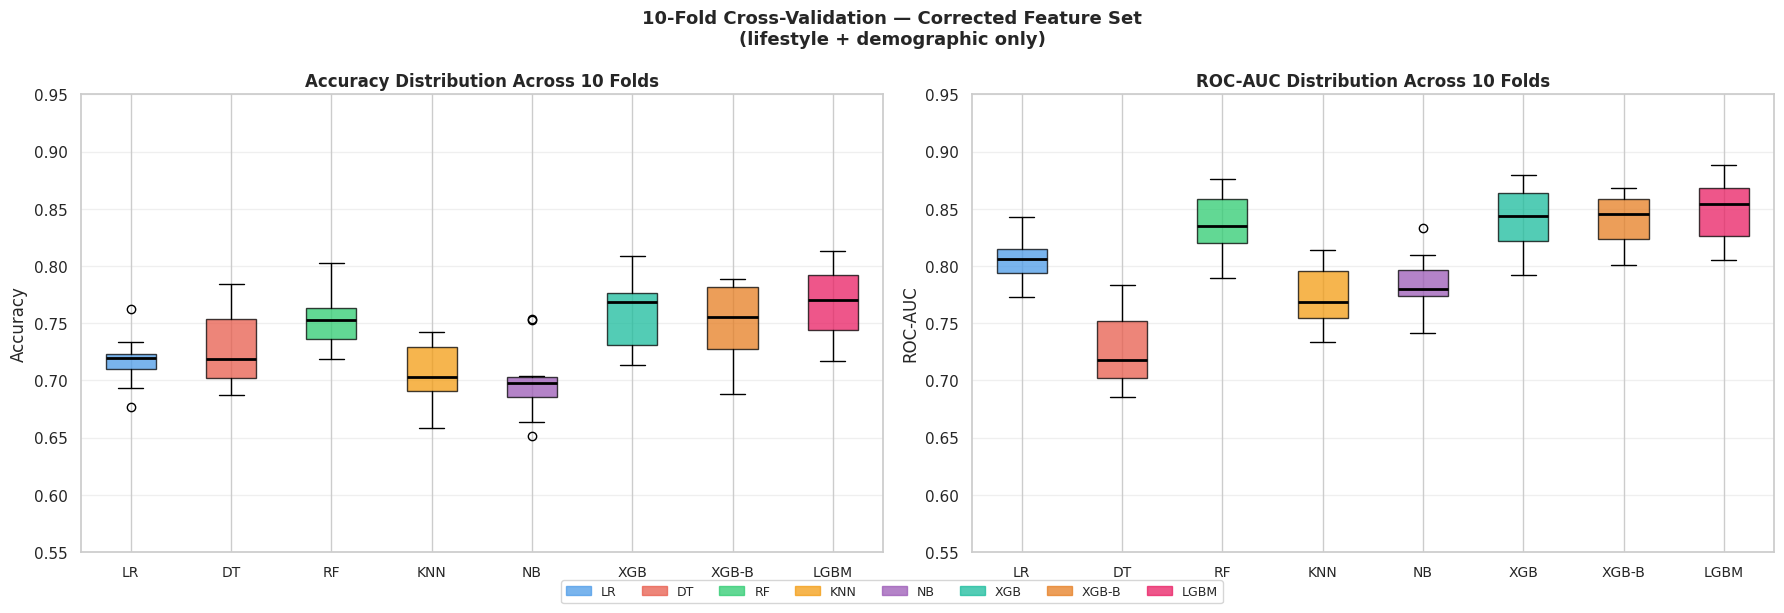

Figure 6 saved.


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('10-Fold Cross-Validation — Corrected Feature Set\n(lifestyle + demographic only)',
             fontsize=13, fontweight='bold')

model_names = list(cv_results.keys())
short_names = ['LR', 'DT', 'RF', 'KNN', 'NB', 'XGB', 'XGB-B', 'LGBM']
colors      = ['#4C9BE8', '#E85C4C', '#2ECC71', '#F39C12',
               '#9B59B6', '#1ABC9C', '#E67E22', '#E91E63']

# Plot 1 — Accuracy across folds (boxplot)
acc_data = [cv_results[name]['Accuracy'] for name in model_names]
bp = axes[0].boxplot(acc_data, patch_artist=True, notch=False,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[0].set_xticks(range(1, len(short_names)+1))
axes[0].set_xticklabels(short_names, fontsize=10)
axes[0].set_title('Accuracy Distribution Across 10 Folds', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.55, 0.95)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, label='Chance')
axes[0].grid(axis='y', alpha=0.3)

# Plot 2 — ROC-AUC across folds (boxplot)
auc_data = [cv_results[name]['ROC-AUC'] for name in model_names]
bp2 = axes[1].boxplot(auc_data, patch_artist=True, notch=False,
                      medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_xticks(range(1, len(short_names)+1))
axes[1].set_xticklabels(short_names, fontsize=10)
axes[1].set_title('ROC-AUC Distribution Across 10 Folds', fontweight='bold')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim(0.55, 0.95)
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.4, label='Chance')
axes[1].grid(axis='y', alpha=0.3)

# Add legend
legend_handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.75) for c in colors]
fig.legend(legend_handles, short_names, loc='lower center',
           ncol=8, fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('fig6_crossvalidation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

Cell 17 — Stability check (are results consistent with single split?):

In [34]:
print('=== STABILITY CHECK ===')
print('Comparing single train-test split vs 10-fold CV mean\n')
print(f"{'Model':<25} {'Split Acc':>10} {'CV Acc':>10} {'Diff':>8} "
      f"{'Split AUC':>10} {'CV AUC':>10} {'Diff':>8}")
print('-' * 85)

for i, name in enumerate(model_names):
    split_acc = results_corr.loc[i, 'Accuracy']
    split_auc = results_corr.loc[i, 'ROC-AUC']
    cv_acc    = cv_results[name]['Accuracy'].mean()
    cv_auc    = cv_results[name]['ROC-AUC'].mean()

    print(f"{name:<25} {split_acc:>10.4f} {cv_acc:>10.4f} "
          f"{abs(split_acc - cv_acc):>8.4f} "
          f"{split_auc:>10.4f} {cv_auc:>10.4f} "
          f"{abs(split_auc - cv_auc):>8.4f}")

print('\nNote: Differences < 0.02 indicate stable, consistent results.')

=== STABILITY CHECK ===
Comparing single train-test split vs 10-fold CV mean

Model                      Split Acc     CV Acc     Diff  Split AUC     CV AUC     Diff
-------------------------------------------------------------------------------------
Logistic Regression           0.7506     0.7174   0.0332     0.8358     0.8070   0.0288
Decision Tree                 0.6977     0.7264   0.0287     0.6941     0.7253   0.0312
Random Forest                 0.7708     0.7532   0.0176     0.8534     0.8377   0.0157
KNN                           0.7280     0.7058   0.0222     0.7975     0.7729   0.0246
Naive Bayes                   0.7204     0.6997   0.0207     0.8170     0.7845   0.0325
XGBoost                       0.7683     0.7602   0.0081     0.8503     0.8417   0.0086
XGBoost (balanced)            0.7657     0.7502   0.0155     0.8651     0.8404   0.0247
LightGBM                      0.7683     0.7688   0.0005     0.8565     0.8484   0.0081

Note: Differences < 0.02 indicate stable, c

Cell 18 — ROC curves for corrected feature set (top 5 models):

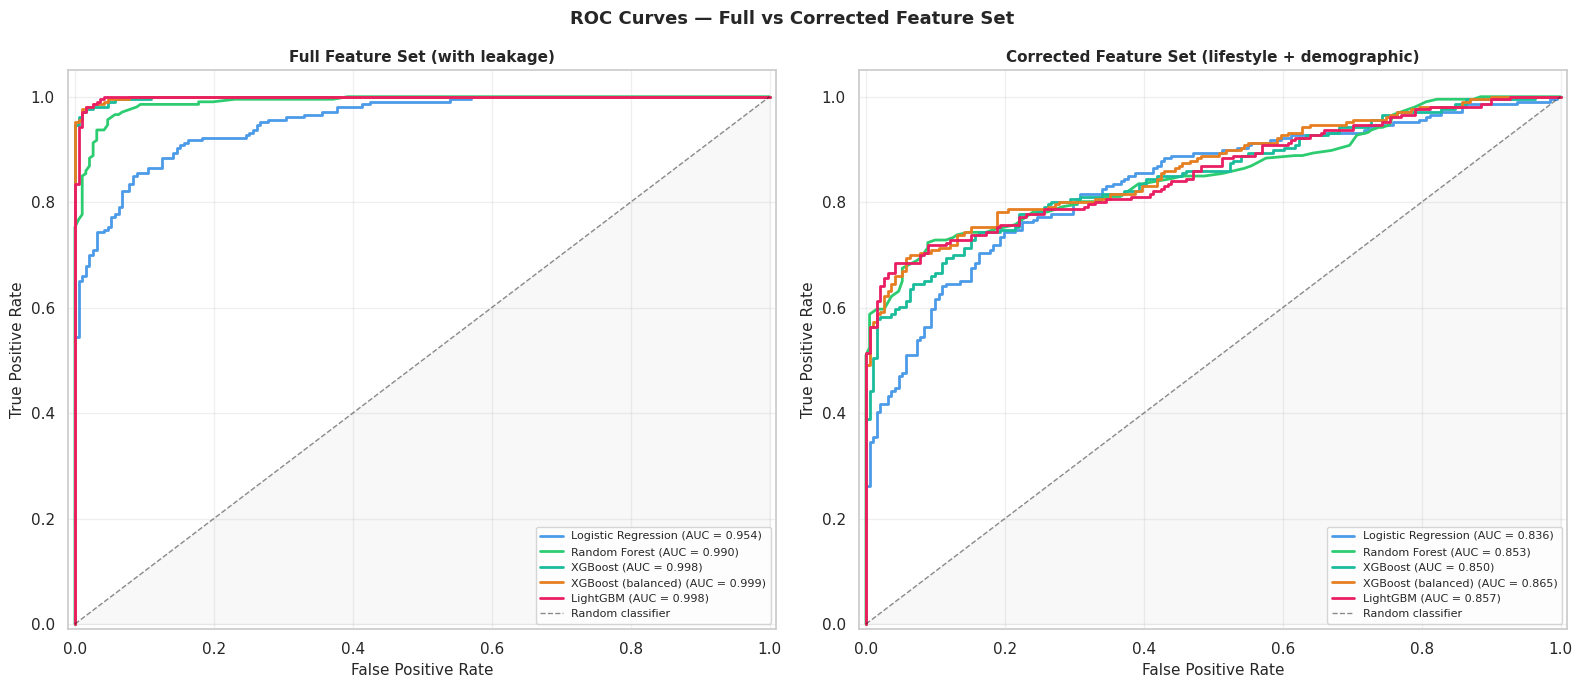

Figure 7 saved.


In [35]:
from sklearn.metrics import roc_curve, roc_auc_score

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Models to plot — top performers only for clarity
top_models = ['Logistic Regression', 'Random Forest',
              'XGBoost', 'XGBoost (balanced)', 'LightGBM']

top_colors = ['#4C9BE8', '#2ECC71', '#1ABC9C', '#E67E22', '#E91E63']

for ax, (results_dict, models_dict, title) in zip(axes, [
    (results_full,  models_full,  'Full Feature Set (with leakage)'),
    (results_corr,  models_corr,  'Corrected Feature Set (lifestyle + demographic)')
]):
    for name, color in zip(top_models, top_colors):
        model  = models_dict[name]
        y_prob = model.predict_proba(
            X_full_test_proc if 'leakage' in title else X_corr_test_proc
        )[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, color=color, lw=2,
                label=f'{name} (AUC = {auc:.3f})')

    ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random classifier')
    ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim([-0.01, 1.01])
    ax.set_ylim([-0.01, 1.05])
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves — Full vs Corrected Feature Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

Cell 19 — Calibration curves (corrected feature set):

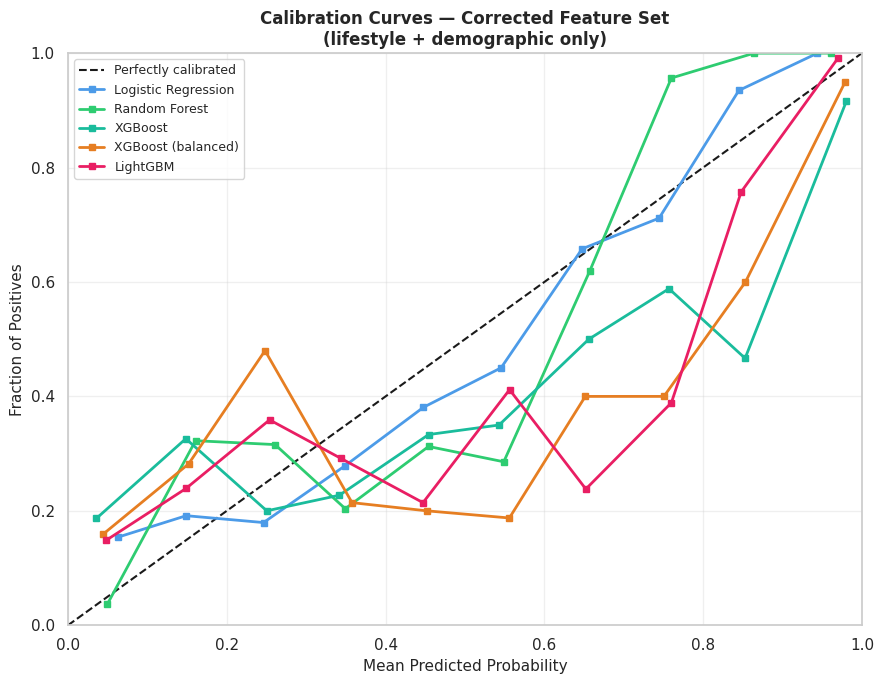

Figure 8 saved.


In [36]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(9, 7))

ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Perfectly calibrated')

for name, color in zip(top_models, top_colors):
    model  = models_corr[name]
    y_prob = model.predict_proba(X_corr_test_proc)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)
    ax.plot(mean_pred, frac_pos, 's-', color=color,
            lw=2, markersize=5, label=name)

ax.set_xlabel('Mean Predicted Probability', fontsize=11)
ax.set_ylabel('Fraction of Positives', fontsize=11)
ax.set_title('Calibration Curves — Corrected Feature Set\n'
             '(lifestyle + demographic only)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig8_calibration.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved.')

Cell 20 — Confusion matrices for top 3 models (corrected set):

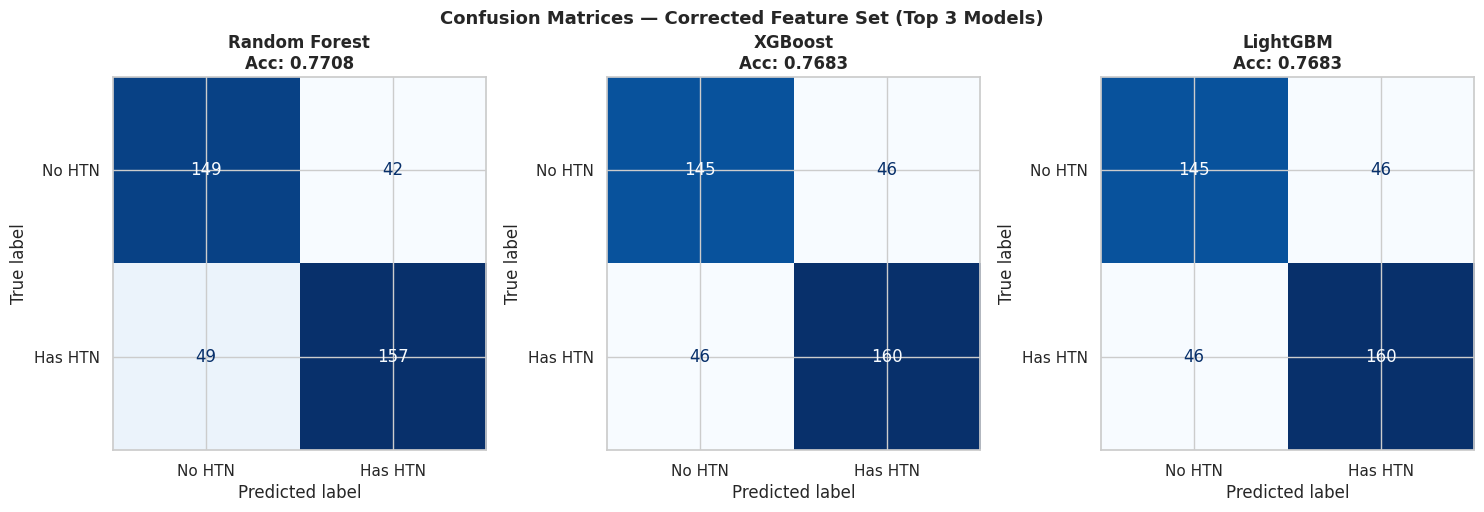

Figure 9 saved.


In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

top3 = ['Random Forest', 'XGBoost', 'LightGBM']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Confusion Matrices — Corrected Feature Set (Top 3 Models)',
             fontsize=13, fontweight='bold')

for ax, name in zip(axes, top3):
    model  = models_corr[name]
    y_pred = model.predict(X_corr_test_proc)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=['No HTN', 'Has HTN'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAcc: {accuracy_score(y_test, y_pred):.4f}',
                 fontweight='bold')

plt.tight_layout()
plt.savefig('fig9_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9 saved.')

 Add Platt scaling calibration:

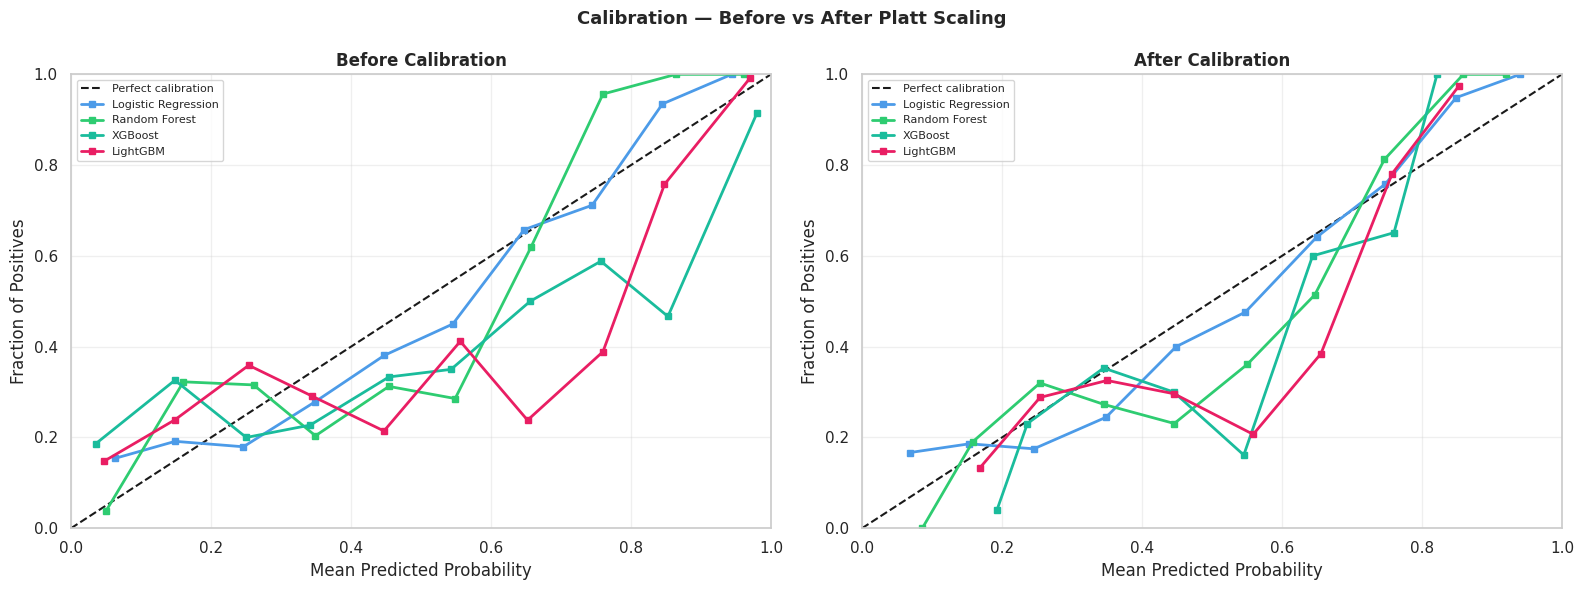

Figure 10 saved.


In [38]:
from sklearn.calibration import CalibratedClassifierCV

# Recalibrate top 3 models using Platt scaling (sigmoid method)
# Fit on training data, evaluate on test data
calibrated_models = {}

for name in ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']:
    base_model = get_models()[name]
    cal_model  = CalibratedClassifierCV(base_model, method='sigmoid', cv=5)
    cal_model.fit(X_corr_train_proc, y_train)
    calibrated_models[f'{name} (calibrated)'] = cal_model

# Compare calibration before and after
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Calibration — Before vs After Platt Scaling',
             fontsize=13, fontweight='bold')

plot_models = {
    'Before': {n: models_corr[n] for n in
               ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM']},
    'After':  calibrated_models
}

colors_cal = ['#4C9BE8', '#2ECC71', '#1ABC9C', '#E91E63']

for ax, (label, mdict) in zip(axes, plot_models.items()):
    ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Perfect calibration')
    for (name, model), color in zip(mdict.items(), colors_cal):
        y_prob = model.predict_proba(X_corr_test_proc)[:, 1]
        frac_pos, mean_pred = calibration_curve(y_test, y_prob, n_bins=10)
        ax.plot(mean_pred, frac_pos, 's-', color=color,
                lw=2, markersize=5,
                label=name.replace(' (calibrated)', ''))
    ax.set_title(f'{label} Calibration', fontweight='bold')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.legend(fontsize=8)
    ax.set_xlim([0,1])
    ax.set_ylim([0,1])
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig10_calibration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 10 saved.')

Step 6 — SHAP and Feature Importance:
Cell 21 — SHAP values for LightGBM (best corrected model):

In [39]:
import shap
shap.initjs()

# Use LightGBM as primary model for SHAP — best CV ROC-AUC
lgbm_model = models_corr['LightGBM']

# SHAP TreeExplainer works natively with LightGBM
explainer   = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_corr_test_proc)

# For binary classification LightGBM returns list [class0, class1]
# We want class 1 (Has Hypertension)
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

print(f'SHAP values shape: {sv.shape}')
print(f'Feature names: {corr_cols}')
print('\n✅ SHAP values computed.')

SHAP values shape: (397, 12)
Feature names: ['Age', 'Salt_Intake', 'Stress_Score', 'Sleep_Duration', 'BMI', 'Family_History_No', 'Family_History_Yes', 'Exercise_Level_High', 'Exercise_Level_Low', 'Exercise_Level_Moderate', 'Smoking_Status_Non-Smoker', 'Smoking_Status_Smoker']

✅ SHAP values computed.


Cell 22 — SHAP summary plot (beeswarm — global feature importance):

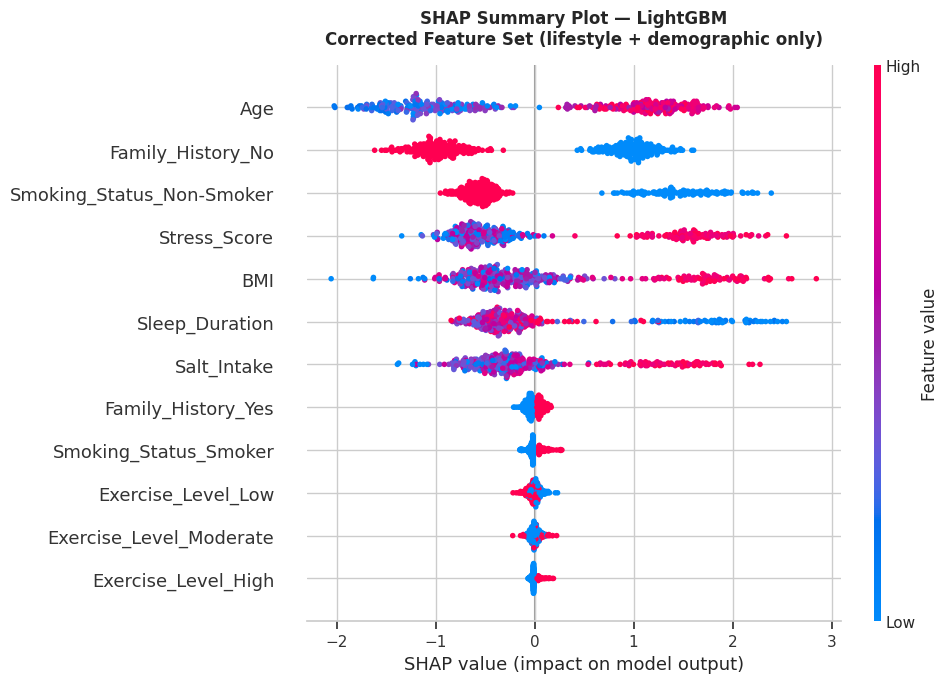

Figure 11 saved.


In [40]:
fig, ax = plt.subplots(figsize=(10, 7))

shap.summary_plot(
    sv,
    X_corr_test_proc,
    feature_names=corr_cols,
    plot_type='dot',
    max_display=12,
    show=False,
    plot_size=None
)

plt.title('SHAP Summary Plot — LightGBM\n'
          'Corrected Feature Set (lifestyle + demographic only)',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig11_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 11 saved.')

Cell 23 — SHAP bar plot (mean absolute impact — cleaner for the paper):

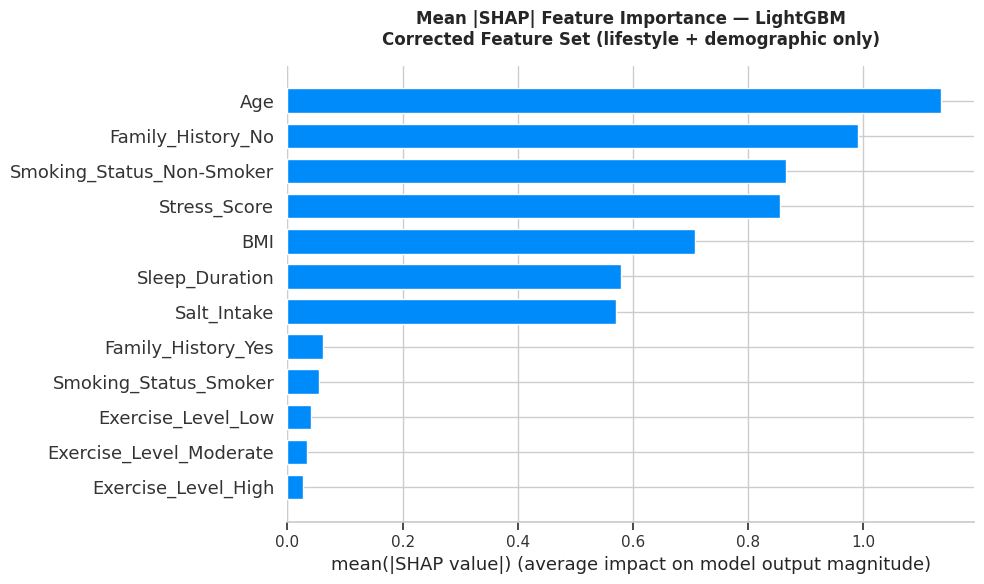

Figure 12 saved.


In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

shap.summary_plot(
    sv,
    X_corr_test_proc,
    feature_names=corr_cols,
    plot_type='bar',
    max_display=12,
    show=False,
    plot_size=None
)

plt.title('Mean |SHAP| Feature Importance — LightGBM\n'
          'Corrected Feature Set (lifestyle + demographic only)',
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig12_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 12 saved.')

Cell 24 — Feature importance comparison across top 3 models:

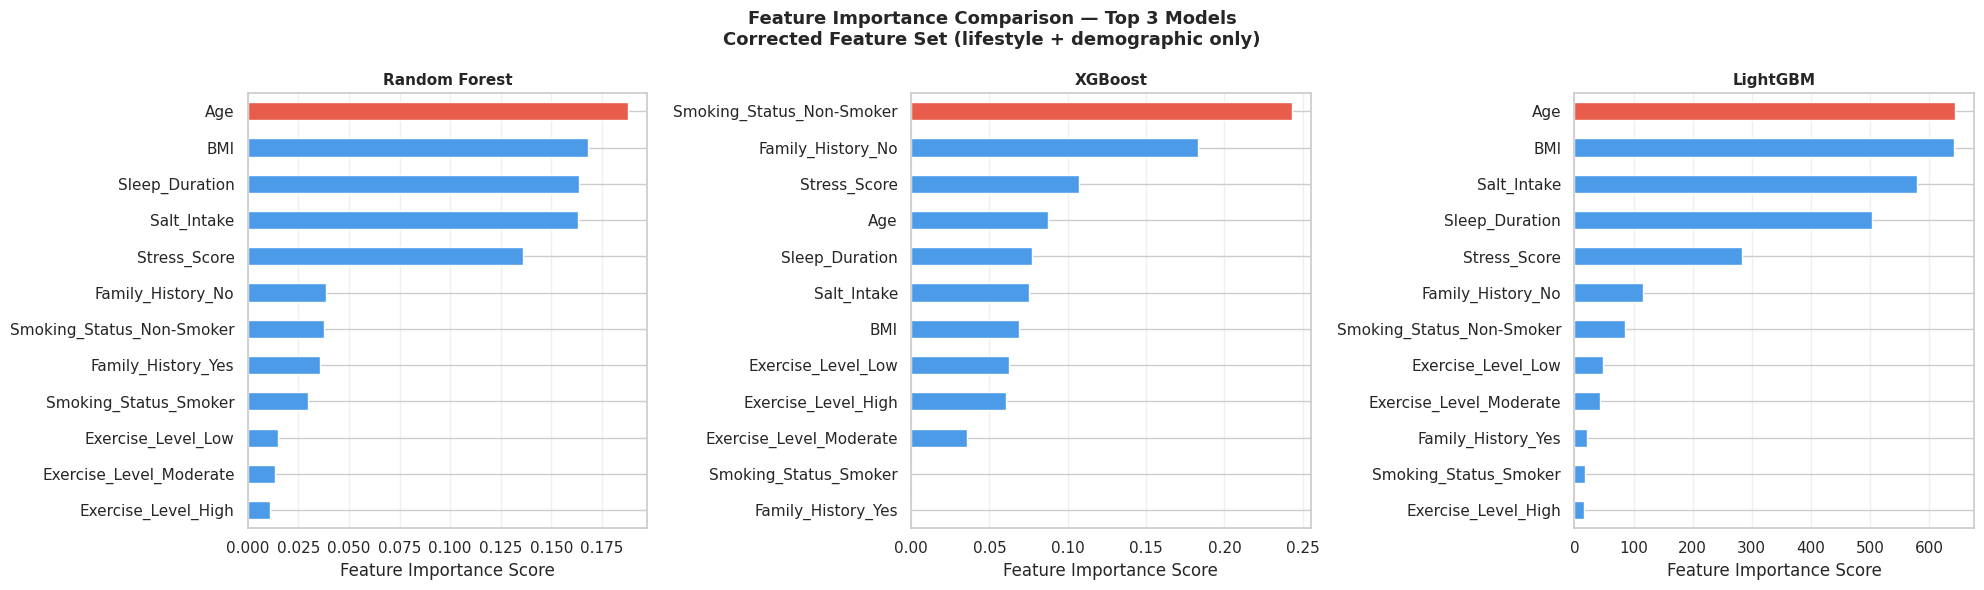

Figure 13 saved.


In [42]:
# Extract and compare feature importance across RF, XGBoost, LightGBM
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Feature Importance Comparison — Top 3 Models\n'
             'Corrected Feature Set (lifestyle + demographic only)',
             fontsize=13, fontweight='bold')

importance_models = {
    'Random Forest': models_corr['Random Forest'],
    'XGBoost':       models_corr['XGBoost'],
    'LightGBM':      models_corr['LightGBM']
}

all_importance = {}

for ax, (name, model) in zip(axes, importance_models.items()):
    importances = model.feature_importances_
    feat_imp    = pd.Series(importances, index=corr_cols).sort_values(ascending=True)
    all_importance[name] = feat_imp

    colors_bar = ['#E85C4C' if v == feat_imp.max()
                  else '#4C9BE8' for v in feat_imp.values]

    feat_imp.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
    ax.set_title(name, fontweight='bold', fontsize=11)
    ax.set_xlabel('Feature Importance Score')
    ax.set_ylabel('')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 13 saved.')

Cell 25 — SHAP dependence plots for top 3 features:

Top 3 features by mean |SHAP|: ['Age', 'Family_History_No', 'Smoking_Status_Non-Smoker']


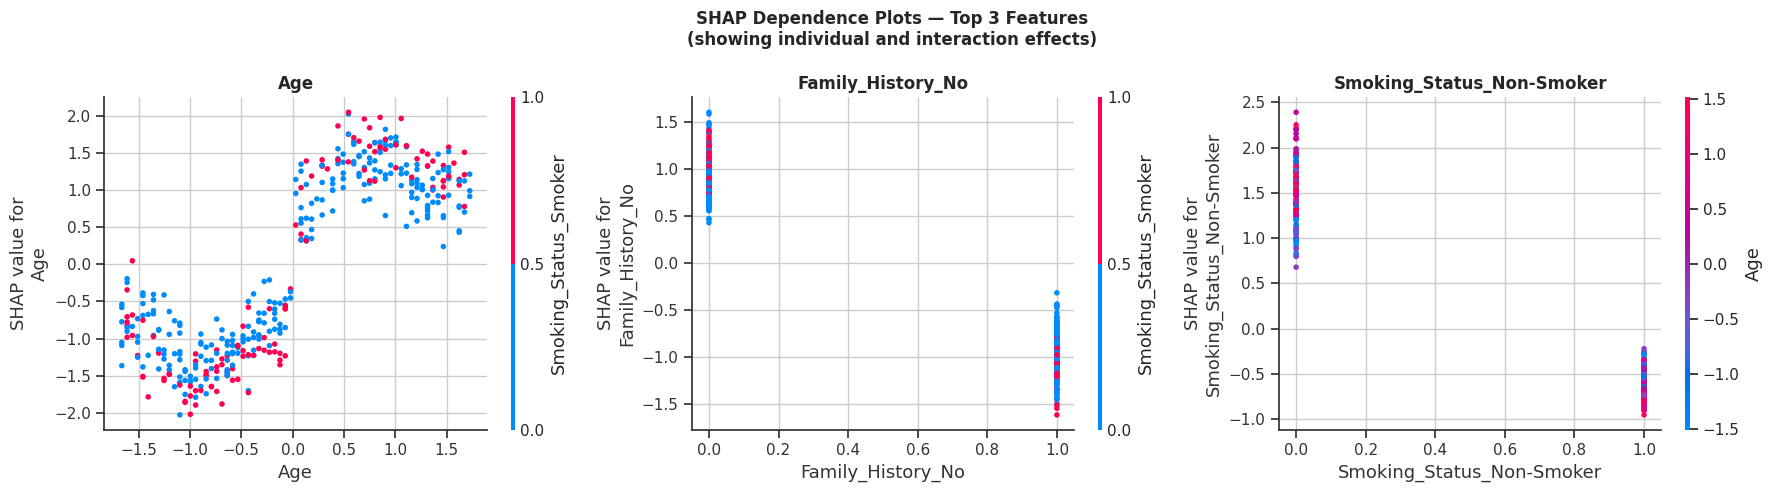

Figure 14 saved.


In [43]:
# Identify top 3 features by mean absolute SHAP
mean_shap   = np.abs(sv).mean(axis=0)
top3_idx    = np.argsort(mean_shap)[::-1][:3]
top3_feats  = [corr_cols[i] for i in top3_idx]

print(f'Top 3 features by mean |SHAP|: {top3_feats}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('SHAP Dependence Plots — Top 3 Features\n'
             '(showing individual and interaction effects)',
             fontsize=12, fontweight='bold')

for ax, feat in zip(axes, top3_feats):
    shap.dependence_plot(
        feat,
        sv,
        X_corr_test_proc,
        feature_names=corr_cols,
        ax=ax,
        show=False
    )
    ax.set_title(feat, fontweight='bold')

plt.tight_layout()
plt.savefig('fig14_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 14 saved.')

Cell 26 — Print ranked SHAP importance table (for manuscript Table 3):

In [45]:
mean_abs_shap = pd.DataFrame({
    'Feature':           corr_cols,
    'Mean |SHAP| Value': np.abs(sv).mean(axis=0)
}).sort_values('Mean |SHAP| Value', ascending=False).reset_index(drop=True)

mean_abs_shap.index += 1  # Start rank from 1
mean_abs_shap['Mean |SHAP| Value'] = mean_abs_shap['Mean |SHAP| Value'].round(4)

print('=== SHAP Feature Importance Ranking (Table 3) ===\n')
print(mean_abs_shap.to_string())

=== SHAP Feature Importance Ranking (Table 3) ===

                      Feature  Mean |SHAP| Value
1                         Age             1.1360
2           Family_History_No             0.9917
3   Smoking_Status_Non-Smoker             0.8662
4                Stress_Score             0.8564
5                         BMI             0.7073
6              Sleep_Duration             0.5801
7                 Salt_Intake             0.5707
8          Family_History_Yes             0.0613
9       Smoking_Status_Smoker             0.0554
10         Exercise_Level_Low             0.0411
11    Exercise_Level_Moderate             0.0337
12        Exercise_Level_High             0.0266


Cell 27 — Save best model and results:

In [46]:
import joblib
import json

# Save the best model (LightGBM — highest CV ROC-AUC)
joblib.dump(models_corr['LightGBM'], 'hypertension_lgbm_corrected.pkl')
joblib.dump(preprocessor_corrected,  'hypertension_preprocessor.pkl')

# Save results tables as CSV for manuscript
results_corr.to_csv('results_corrected_featureset.csv', index=False)
results_full.to_csv('results_full_featureset.csv',      index=False)
cv_df.to_csv('results_crossvalidation.csv',             index=False)
mean_abs_shap.to_csv('shap_importance_table3.csv',      index=False)

# Save SHAP values
np.save('shap_values_lgbm.npy', sv)

print('✅ All outputs saved:')
print('  hypertension_lgbm_corrected.pkl  — trained LightGBM model')
print('  hypertension_preprocessor.pkl    — fitted preprocessor')
print('  results_corrected_featureset.csv — Table 2 data')
print('  results_full_featureset.csv      — leakage comparison data')
print('  results_crossvalidation.csv      — CV results')
print('  shap_importance_table3.csv       — Table 3 data')
print('  shap_values_lgbm.npy             — SHAP values array')

✅ All outputs saved:
  hypertension_lgbm_corrected.pkl  — trained LightGBM model
  hypertension_preprocessor.pkl    — fitted preprocessor
  results_corrected_featureset.csv — Table 2 data
  results_full_featureset.csv      — leakage comparison data
  results_crossvalidation.csv      — CV results
  shap_importance_table3.csv       — Table 3 data
  shap_values_lgbm.npy             — SHAP values array


Download everything from Colab first

In [47]:
import shutil
import os

# List of all files to include in GitHub repo
files_to_save = [
    'hypertention.csv',
    'hypertension_lgbm_corrected.pkl',
    'hypertension_preprocessor.pkl',
    'results_corrected_featureset.csv',
    'results_full_featureset.csv',
    'results_crossvalidation.csv',
    'shap_importance_table3.csv',
    'fig1_numerical_distributions.png',
    'fig2_categorical_distributions.png',
    'fig3_correlation_heatmap.png',
    'fig4_target_distribution.png',
    'fig5_model_comparison.png',
    'fig6_crossvalidation.png',
    'fig7_roc_curves.png',
    'fig8_calibration.png',
    'fig9_confusion_matrices.png',
    'fig10_calibration_comparison.png',
    'fig11_shap_summary.png',
    'fig12_shap_bar.png',
    'fig13_feature_importance.png',
    'fig14_shap_dependence.png',
]

# Create folder structure
os.makedirs('hypertension_repo/data',    exist_ok=True)
os.makedirs('hypertension_repo/figures', exist_ok=True)
os.makedirs('hypertension_repo/models',  exist_ok=True)
os.makedirs('hypertension_repo/results', exist_ok=True)

# Copy files to correct folders
for f in files_to_save:
    if not os.path.exists(f):
        print(f'  ⚠️  Not found: {f}')
        continue
    if f.endswith('.csv') and 'results' not in f and 'shap' not in f:
        shutil.copy(f, f'hypertension_repo/data/{f}')
    elif f.endswith('.png'):
        shutil.copy(f, f'hypertension_repo/figures/{f}')
    elif f.endswith('.pkl'):
        shutil.copy(f, f'hypertension_repo/models/{f}')
    elif f.endswith('.csv'):
        shutil.copy(f, f'hypertension_repo/results/{f}')

# Save the notebook itself
shutil.copy('hypertension.ipynb',
            'hypertension_repo/hypertension_analysis.ipynb') \
    if os.path.exists('hypertension.ipynb') else None

# Zip everything
shutil.make_archive('hypertension_github_repo', 'zip', 'hypertension_repo')

print('✅ Zipped. Downloading now...')

from google.colab import files
files.download('hypertension_github_repo.zip')

✅ Zipped. Downloading now...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>